In [113]:
# Data handling
import pandas as pd
import numpy as np

# For scaling and encoding
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# For splitting dataset
from sklearn.model_selection import train_test_split

# For machine learning models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# For evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
df=pd.read_csv("air_quality_new_dataset.csv")
df

,CO2,NO2,TEMPERATURE,HUMIDITY,PM2.5,PM10,SO2,O3,WIND_SPEED,AIR_QUALITY
0,1.518630,56.841123,21.258148,64.891639,8.046328,50.220630,33.154245,24.425165,1.450581,Moderate
1,0.245631,41.148329,24.711794,NaN,18.256189,0.000000,14.647185,64.451439,6.977132,Good
2,1.590041,-0.336604,28.726544,55.746668,99.070981,67.271799,34.208575,23.736400,2.981163,Poor
3,0.774381,59.249483,34.029814,46.347051,27.002722,171.080898,11.889519,50.285071,4.891567,Moderate
4,0.735228,35.969293,NaN,79.366808,73.774756,186.748922,28.008081,40.592361,5.941749,Moderate
...,...,...,...,...,...,...,...,...,...,...
1055,0.840751,NaN,27.058858,37.684552,43.975654,22.390375,22.364834,75.628524,2.584804,Moderate
1056,0.714282,42.373736,19.647686,57.839246,20.283200,49.835967,48.829097,27.744563,4.761993,Moderate
1057,1.812964,59.059309,25.813970,30.498939,140.710901,79.187406,24.868044,12.685470,4.819501,Poor
1058,1.794760,24.356898,20.377070,NaN,109.002972,175.598160,27.091082,65.171185,5.283157,Poor


In [114]:
df.describe()

,CO2,NO2,TEMPERATURE,HUMIDITY,PM2.5,PM10,SO2,O3,WIND_SPEED
count,1006.000000,1003.000000,1001.000000,998.000000,1005.000000,1004.000000,1005.000000,1004.000000,1005.000000
mean,1.102067,35.842428,24.738609,55.366844,78.396511,107.519376,26.314637,44.347631,5.455503
std,0.600056,18.767184,6.441777,16.187629,47.243726,60.243587,15.197182,22.609214,2.525283
min,-0.443059,-0.424237,-7.996736,30.001536,0.000000,0.000000,-0.308885,0.000000,1.000475
25%,0.627993,22.341442,20.190836,42.194280,41.047708,59.182035,14.607374,26.301907,3.369216
50%,1.112149,35.740868,24.933908,55.009782,75.998391,105.026588,25.704114,43.672356,5.461453
75%,1.559806,47.912542,29.837927,67.105013,113.056138,152.048587,38.187592,60.041041,7.528506
max,8.626956,296.812187,34.956417,141.041589,471.509318,558.308201,241.966139,238.266574,9.987556


In [115]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nInfo:\n")
df.info()

Shape: (1060, 10)

Columns:
 Index(['CO2', 'NO2', 'TEMPERATURE', 'HUMIDITY', 'PM2.5', 'PM10', 'SO2', 'O3',
       'WIND_SPEED', 'AIR_QUALITY'],
      dtype='object')

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1060 entries, 0 to 1059
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CO2          1006 non-null   float64
 1   NO2          1003 non-null   float64
 2   TEMPERATURE  1001 non-null   float64
 3   HUMIDITY     998 non-null    float64
 4   PM2.5        1005 non-null   float64
 5   PM10         1004 non-null   float64
 6   SO2          1005 non-null   float64
 7   O3           1004 non-null   float64
 8   WIND_SPEED   1005 non-null   float64
 9   AIR_QUALITY  1060 non-null   object 
dtypes: float64(9), object(1)
memory usage: 82.9+ KB


In [81]:
df.head()

,CO2,NO2,TEMPERATURE,HUMIDITY,PM2.5,PM10,SO2,O3,WIND_SPEED,AIR_QUALITY
0,1.518630,56.841123,21.258148,64.891639,8.046328,50.220630,33.154245,24.425165,1.450581,Moderate
1,0.245631,41.148329,24.711794,NaN,18.256189,0.000000,14.647185,64.451439,6.977132,Good
2,1.590041,-0.336604,28.726544,55.746668,99.070981,67.271799,34.208575,23.736400,2.981163,Poor
3,0.774381,59.249483,34.029814,46.347051,27.002722,171.080898,11.889519,50.285071,4.891567,Moderate
4,0.735228,35.969293,NaN,79.366808,73.774756,186.748922,28.008081,40.592361,5.941749,Moderate


In [117]:
df.tail()

,CO2,NO2,TEMPERATURE,HUMIDITY,PM2.5,PM10,SO2,O3,WIND_SPEED,AIR_QUALITY
1055,0.840751,NaN,27.058858,37.684552,43.975654,22.390375,22.364834,75.628524,2.584804,Moderate
1056,0.714282,42.373736,19.647686,57.839246,20.283200,49.835967,48.829097,27.744563,4.761993,Moderate
1057,1.812964,59.059309,25.813970,30.498939,140.710901,79.187406,24.868044,12.685470,4.819501,Poor
1058,1.794760,24.356898,20.377070,NaN,109.002972,175.598160,27.091082,65.171185,5.283157,Poor
1059,1.595950,25.280211,18.904812,31.733635,140.265815,NaN,37.304789,NaN,5.083784,Poor


In [118]:
df.isnull().sum()

CO2            54
NO2            57
TEMPERATURE    59
HUMIDITY       62
PM2.5          55
PM10           56
SO2            55
O3             56
WIND_SPEED     55
AIR_QUALITY     0
dtype: int64

In [120]:
df.duplicated().sum()

9

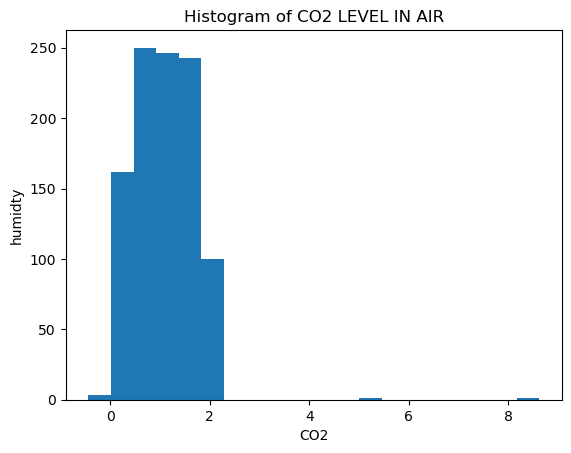

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
plt.hist(df["CO2"], bins=20,)
plt.title('Histogram of CO2 LEVEL IN AIR')
plt.xlabel("CO2")
plt.ylabel('humidty')
plt.show()

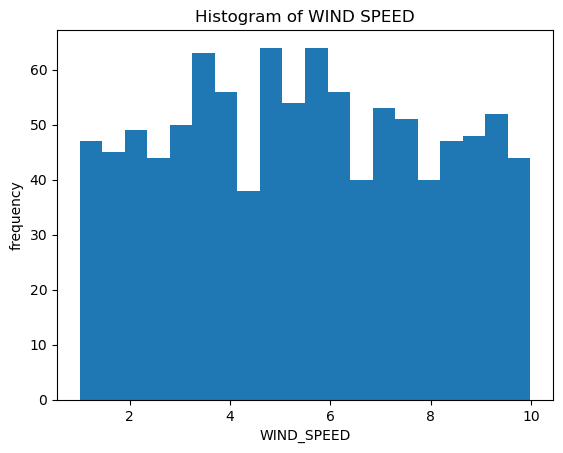

In [122]:
plt.figure()
plt.hist(df["WIND_SPEED"], bins=20,)
plt.title('Histogram of WIND SPEED')
plt.xlabel("WIND_SPEED")
plt.ylabel('frequency')
plt.show()

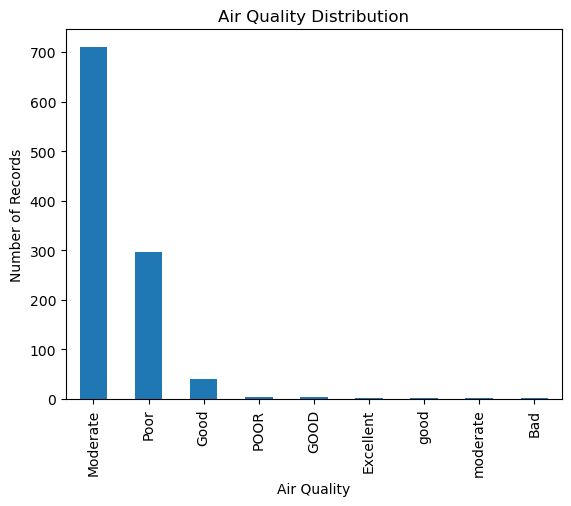

In [123]:
plt.figure()
df["AIR_QUALITY"].value_counts().plot(kind="bar")
plt.xlabel("Air Quality")
plt.ylabel("Number of Records")
plt.title("Air Quality Distribution")
plt.show()

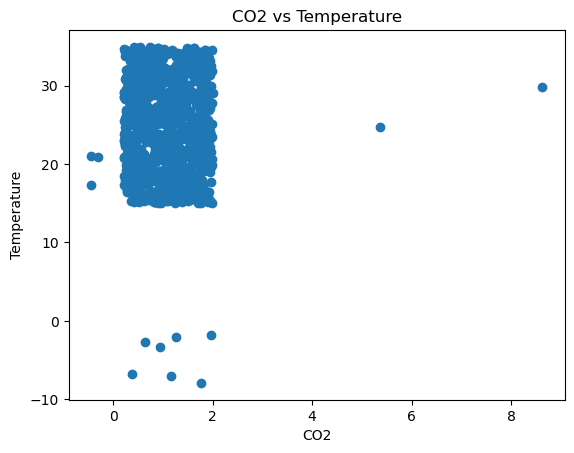

In [124]:
plt.figure()
plt.scatter(df["CO2"], df["TEMPERATURE"])
plt.xlabel("CO2")
plt.ylabel("Temperature")
plt.title("CO2 vs Temperature")
plt.show()

In [89]:
for col in ['CO2', 'NO2', 'TEMPERATURE', 'HUMIDITY']: 
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} -> Number of Outliers: {outliers.shape[0]}")

CO2 -> Number of Outliers: 2
NO2 -> Number of Outliers: 4
TEMPERATURE -> Number of Outliers: 9
HUMIDITY -> Number of Outliers: 11


In [125]:
# 1. Define all 10 columns for your air quality project
# Note: Ensure names match exactly (e.g., 'TEMPERATURE' vs 'TEMPRATURE')
cols = [
    'CO2', 'NO2', 'TEMPERATURE', 'HUMIDITY', 
    'PM2.5', 'PM10', 'SO2', 'O3', 'WIND_SPEED', 'AIR_QUALITY'
]

# 2. Loop through all 10 columns to remove outliers
for col in cols:
    # Skip target column if it's already encoded as text
    if df[col].dtype == 'object':
        continue
        
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Filter the DataFrame to keep only non-outliers
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    
    # Optional: Print results for each column
    outliers_count = len(df[(df[col] < lower) | (df[col] > upper)])
    print(f"{col} -> Remaining Outliers: {outliers_count}")

print(f"Final dataset size after cleaning all 10 columns: {df.shape}")

CO2 -> Remaining Outliers: 0
NO2 -> Remaining Outliers: 0
TEMPERATURE -> Remaining Outliers: 0
HUMIDITY -> Remaining Outliers: 0
PM2.5 -> Remaining Outliers: 0
PM10 -> Remaining Outliers: 0
SO2 -> Remaining Outliers: 0
O3 -> Remaining Outliers: 0
WIND_SPEED -> Remaining Outliers: 0
Final dataset size after cleaning all 10 columns: (646, 10)


In [90]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = ["CO2", "NO2", "TEMPERATURE", "HUMIDITY" ,"PM2.5" , "PM10" , "SO2" , "O3"]
scaler = StandardScaler()

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
df

,CO2,NO2,TEMPERATURE,HUMIDITY,PM2.5,PM10,SO2,O3,WIND_SPEED,AIR_QUALITY
0,0.694552,1.119463,-0.540565,0.588695,-1.489832,-0.951592,0.450282,-0.881605,1.450581,Moderate
1,-1.427969,0.282863,-0.004165,NaN,-1.273614,-1.785633,-0.768120,0.889630,6.977132,Good
2,0.813618,-1.928743,0.619383,0.023476,0.437831,-0.668414,0.519693,-0.912084,2.981163,Poor
3,-0.546364,1.247855,1.443057,-0.557482,-1.088385,1.055601,-0.949670,0.262742,4.891567,Moderate
4,-0.611644,0.006763,NaN,1.483355,-0.097877,1.315809,0.111487,-0.166177,5.941749,Moderate
...,...,...,...,...,...,...,...,...,...,...
1055,-0.435702,NaN,0.360368,-1.092881,-0.728943,-1.413784,-0.260033,1.384236,2.584804,Moderate
1056,-0.646569,0.348191,-0.790693,0.152811,-1.230687,-0.957980,1.482227,-0.734716,4.761993,Moderate
1057,1.185308,1.237717,0.167019,-1.536999,1.319655,-0.470525,-0.095236,-1.401108,4.819501,Poor
1058,1.154955,-0.612306,-0.677409,NaN,0.648164,1.130622,0.051117,0.921480,5.283157,Poor


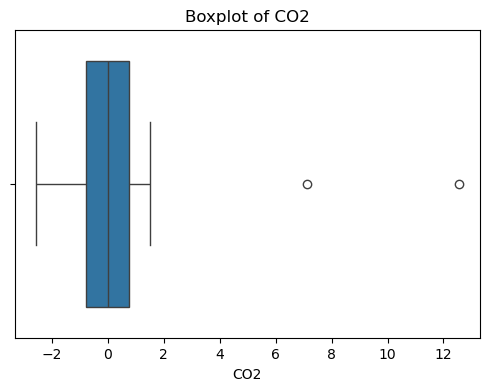

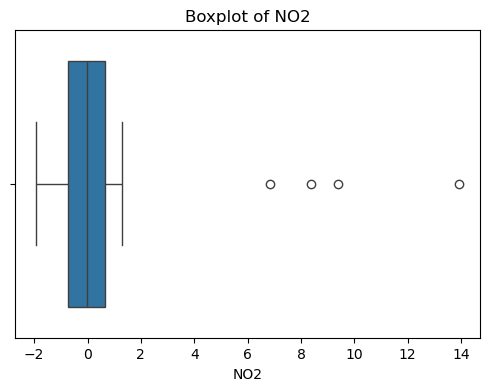

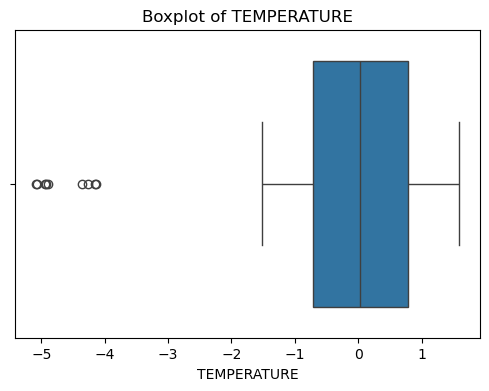

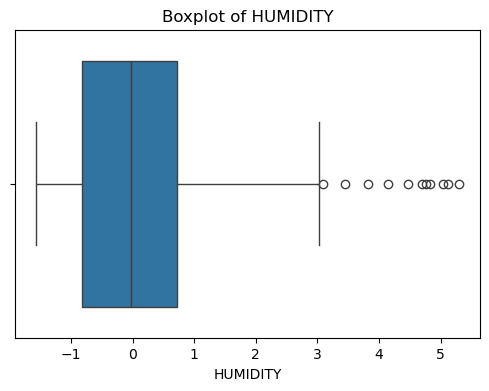

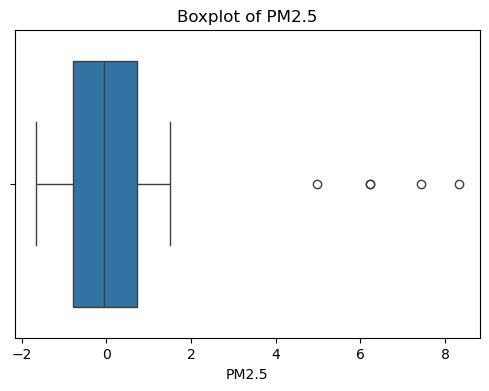

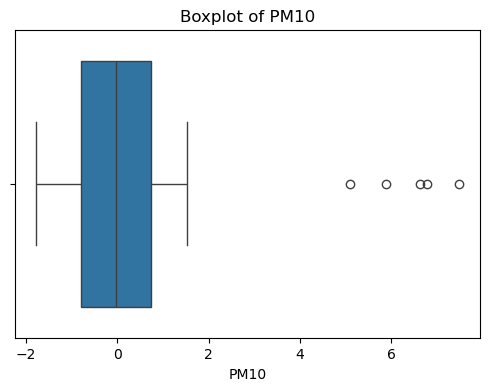

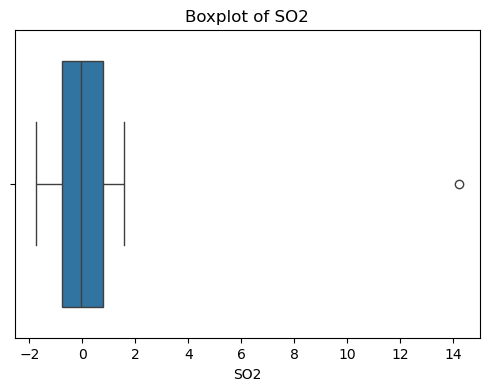

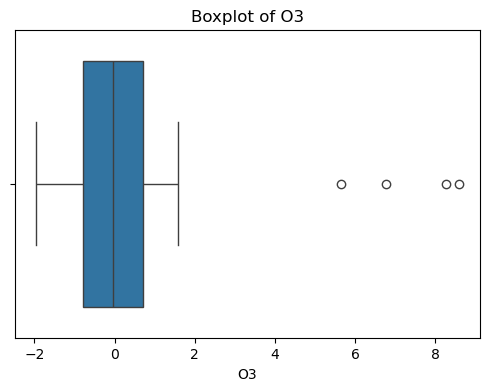

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_columns = ["CO2", "NO2", "TEMPERATURE", "HUMIDITY" ,"PM2.5" , "PM10" , "SO2" , "O3"]

for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

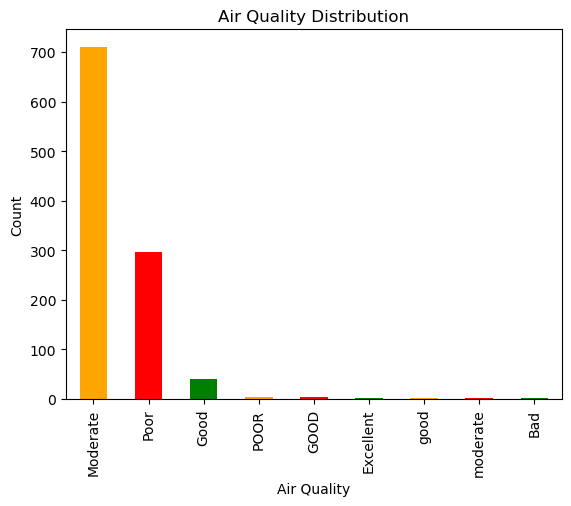

In [92]:
label_mapping = {0: "Good", 1: "Moderate", 2: "Poor"}
df['AIRR_QUALITY'] = df['AIR_QUALITY'].map(label_mapping)

df['AIR_QUALITY'].value_counts().plot(kind="bar", color=['orange', 'red', 'green'])
plt.xlabel("Air Quality")
plt.ylabel("Count")
plt.title("Air Quality Distribution")
plt.show()

In [112]:
print(df_clean.columns.tolist())

['CO2', 'NO2 ', 'TEMPRATURE', 'HUMIDITY', 'AIR_QUALITY']


In [126]:
# Drop rows with any missing values across the 10 columns
df = df.dropna()

print(f"Rows remaining after removing missing values: {len(df)}")

Rows remaining after removing missing values: 646


In [127]:
# Remove identical rows from the dataset
df = df.drop_duplicates()

# Reset the index to keep it continuous (0, 1, 2...)
df = df.reset_index(drop=True)

print(f"Final dataset size: {df.shape}")
df.head()

Final dataset size: (645, 10)


,CO2,NO2,TEMPERATURE,HUMIDITY,PM2.5,PM10,SO2,O3,WIND_SPEED,AIR_QUALITY
0,1.518630,56.841123,21.258148,64.891639,8.046328,50.220630,33.154245,24.425165,1.450581,Moderate
1,1.590041,-0.336604,28.726544,55.746668,99.070981,67.271799,34.208575,23.736400,2.981163,Poor
2,0.774381,59.249483,34.029814,46.347051,27.002722,171.080898,11.889519,50.285071,4.891567,Moderate
3,1.695115,46.867854,24.977913,50.658626,52.536539,182.935830,14.343436,43.678798,6.425268,Poor
4,1.631335,23.841390,34.760719,64.856790,89.800033,65.893293,47.018800,43.389434,1.610168,Moderate


In [128]:
print(list(df.columns))

['CO2', 'NO2', 'TEMPERATURE', 'HUMIDITY', 'PM2.5', 'PM10', 'SO2', 'O3', 'WIND_SPEED', 'AIR_QUALITY']


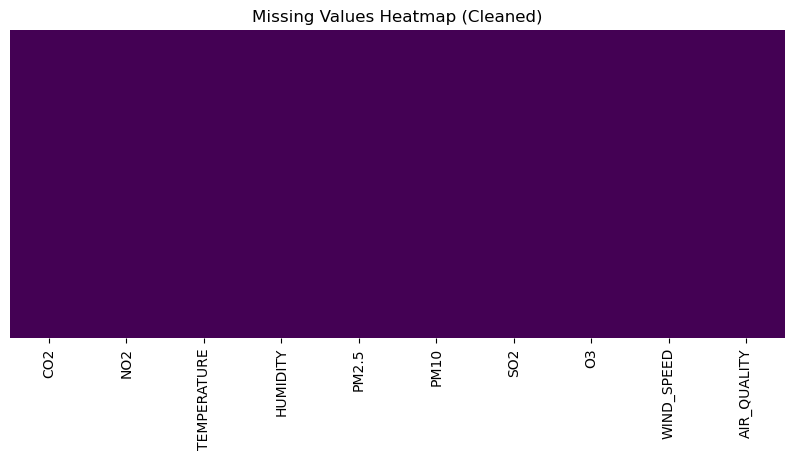

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap (Cleaned)")
plt.show()

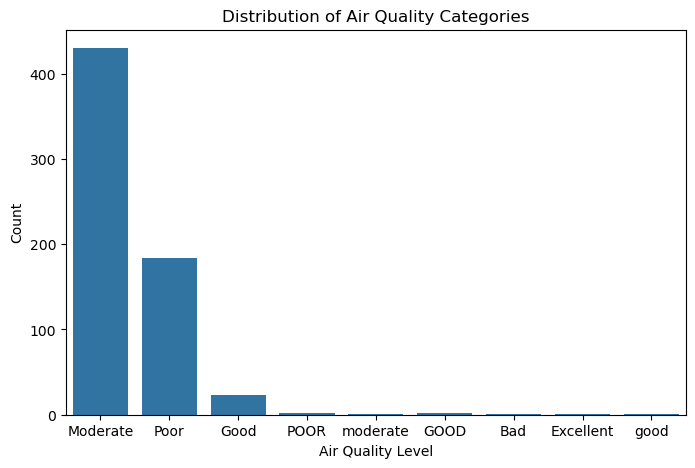

In [131]:
plt.figure(figsize=(8, 5))
sns.countplot(x='AIR_QUALITY', data=df)
plt.title("Distribution of Air Quality Categories")
plt.xlabel("Air Quality Level")
plt.ylabel("Count")
plt.show()

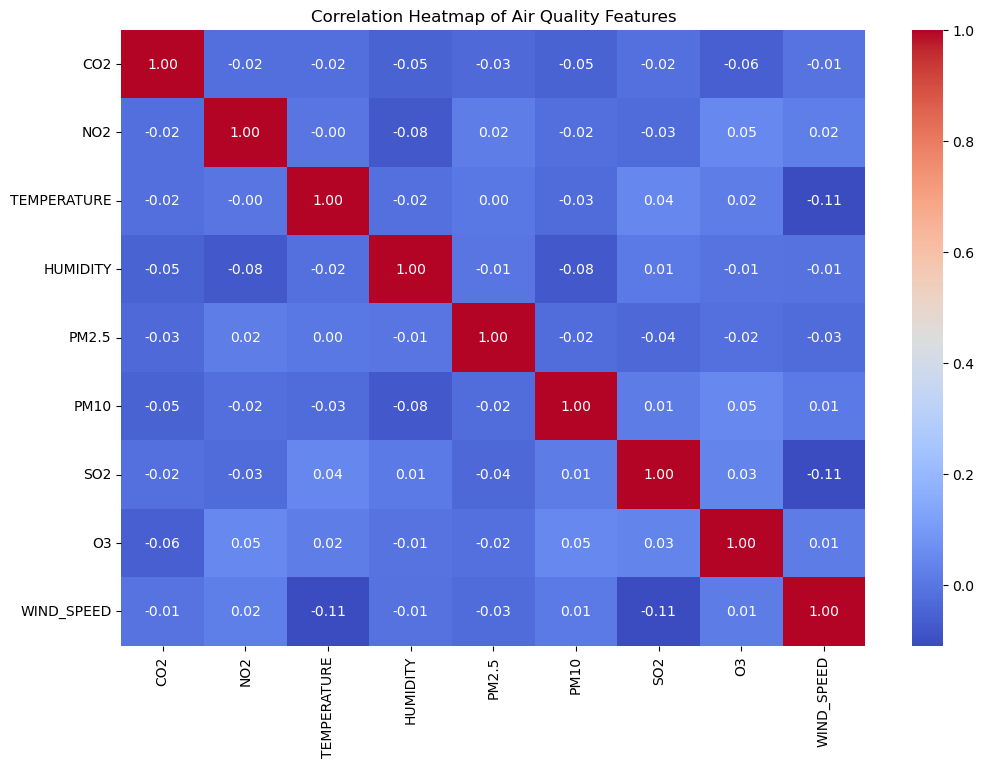

In [132]:
plt.figure(figsize=(12, 8))
# We only calculate correlation for numerical columns
correlation_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Air Quality Features")
plt.show()

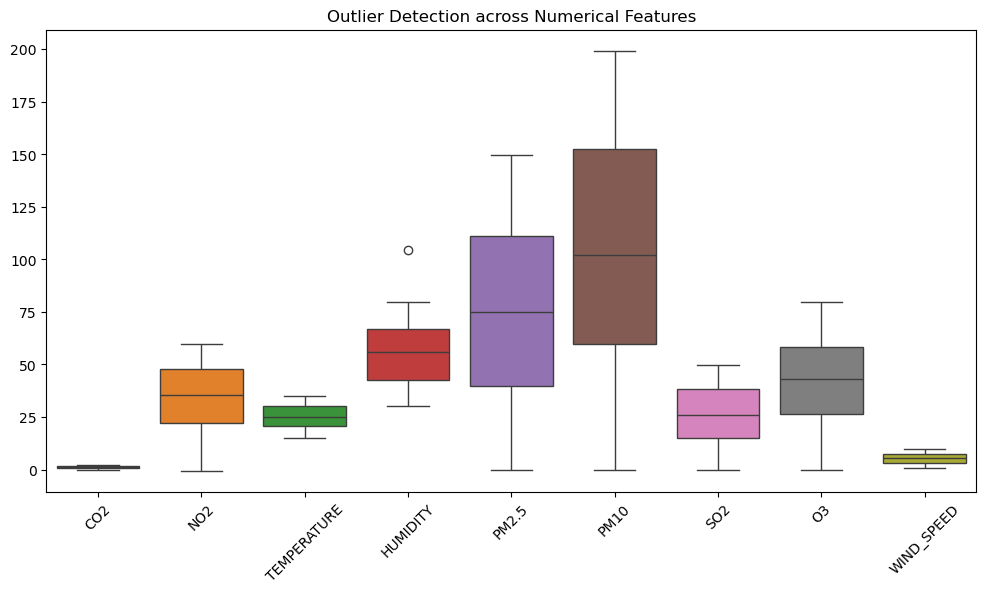

In [133]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting boxplots for all numerical columns
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include=['number']))
plt.title('Outlier Detection across Numerical Features')
plt.xticks(rotation=45)
plt.show()

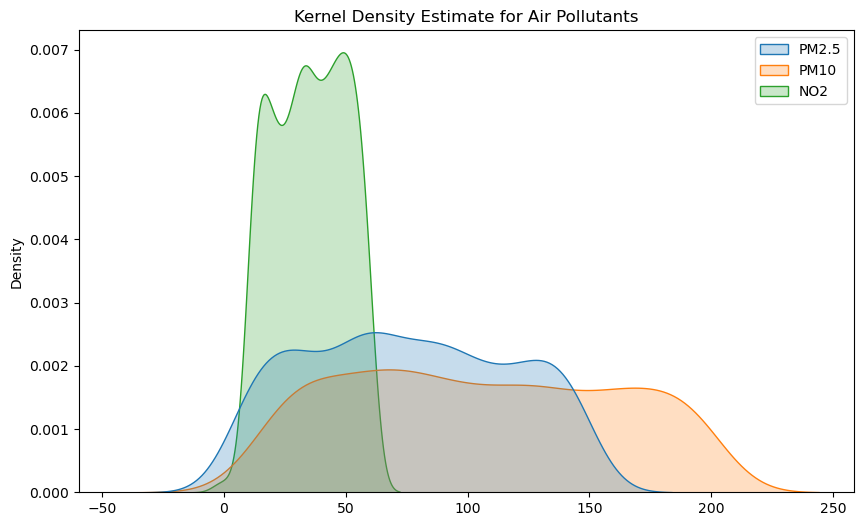

In [134]:
#for specific polutants
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[['PM2.5', 'PM10', 'NO2']], fill=True)
plt.title('Kernel Density Estimate for Air Pollutants')
plt.show()

In [140]:
for col in df.columns[:-1]:   
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} -> Number of Outliers: {outliers.shape[0]}")

CO2 -> Number of Outliers: 0
NO2 -> Number of Outliers: 0
TEMPERATURE -> Number of Outliers: 0
HUMIDITY -> Number of Outliers: 1
PM2.5 -> Number of Outliers: 0
PM10 -> Number of Outliers: 0
SO2 -> Number of Outliers: 0
O3 -> Number of Outliers: 0
WIND_SPEED -> Number of Outliers: 0


In [146]:
df['HUMIDITY'] = df['HUMIDITY'].clip(lower, upper)
print(df)

          CO2        NO2  TEMPERATURE   HUMIDITY       PM2.5        PM10  \
0    1.518630  56.841123    21.258148  13.795373    8.046328   50.220630   
1    1.590041  -0.336604    28.726544  13.795373   99.070981   67.271799   
2    0.774381  59.249483    34.029814  13.795373   27.002722  171.080898   
3    1.695115  46.867854    24.977913  13.795373   52.536539  182.935830   
4    1.631335  23.841390    34.760719  13.795373   89.800033   65.893293   
..        ...        ...          ...        ...         ...         ...   
640  1.525600  22.612051    16.092688  13.795373   17.779492  106.201801   
641  0.980933  35.988697    31.672999  13.795373   46.076239  194.925124   
642  1.678263  29.096982    22.061008  13.795373   66.930232   31.552528   
643  0.714282  42.373736    19.647686  13.795373   20.283200   49.835967   
644  1.812964  59.059309    25.813970  13.795373  140.710901   79.187406   

           SO2         O3  WIND_SPEED AIR_QUALITY  
0    33.154245  24.425165    1.4505

In [145]:
df = df[(df['HUMIDITY'] >= lower) & (df['HUMIDITY'] <= upper)]
print(df)

          CO2        NO2  TEMPERATURE   HUMIDITY       PM2.5        PM10  \
0    1.518630  56.841123    21.258148  13.795373    8.046328   50.220630   
1    1.590041  -0.336604    28.726544  13.795373   99.070981   67.271799   
2    0.774381  59.249483    34.029814  13.795373   27.002722  171.080898   
3    1.695115  46.867854    24.977913  13.795373   52.536539  182.935830   
4    1.631335  23.841390    34.760719  13.795373   89.800033   65.893293   
..        ...        ...          ...        ...         ...         ...   
640  1.525600  22.612051    16.092688  13.795373   17.779492  106.201801   
641  0.980933  35.988697    31.672999  13.795373   46.076239  194.925124   
642  1.678263  29.096982    22.061008  13.795373   66.930232   31.552528   
643  0.714282  42.373736    19.647686  13.795373   20.283200   49.835967   
644  1.812964  59.059309    25.813970  13.795373  140.710901   79.187406   

           SO2         O3  WIND_SPEED AIR_QUALITY  
0    33.154245  24.425165    1.4505

In [147]:
for col in df.columns[:-1]:   
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} -> Number of Outliers: {outliers.shape[0]}")

CO2 -> Number of Outliers: 0
NO2 -> Number of Outliers: 0
TEMPERATURE -> Number of Outliers: 0
HUMIDITY -> Number of Outliers: 0
PM2.5 -> Number of Outliers: 0
PM10 -> Number of Outliers: 0
SO2 -> Number of Outliers: 0
O3 -> Number of Outliers: 0
WIND_SPEED -> Number of Outliers: 0


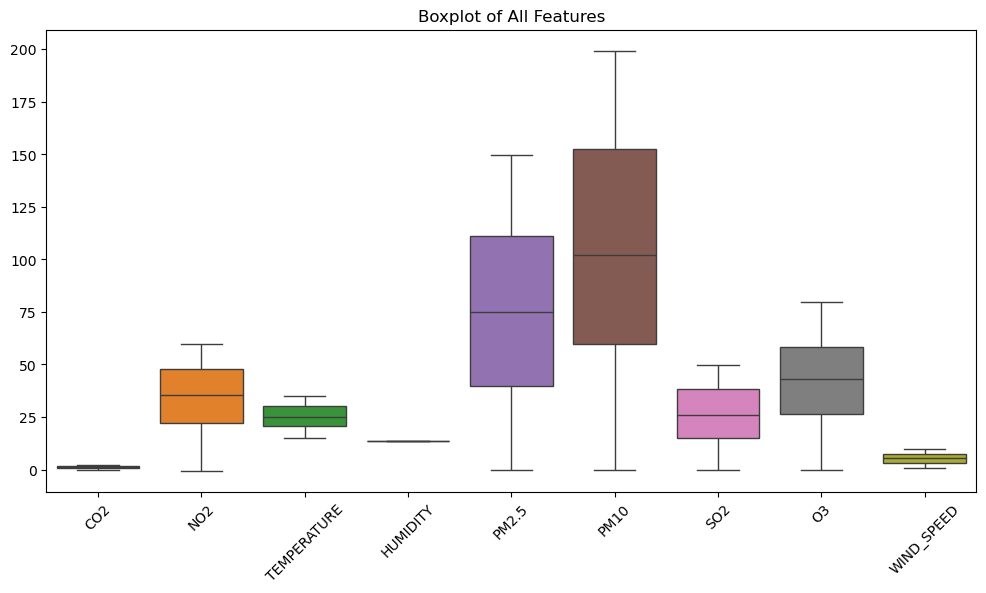

In [149]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title('Boxplot of All Features')
plt.show()

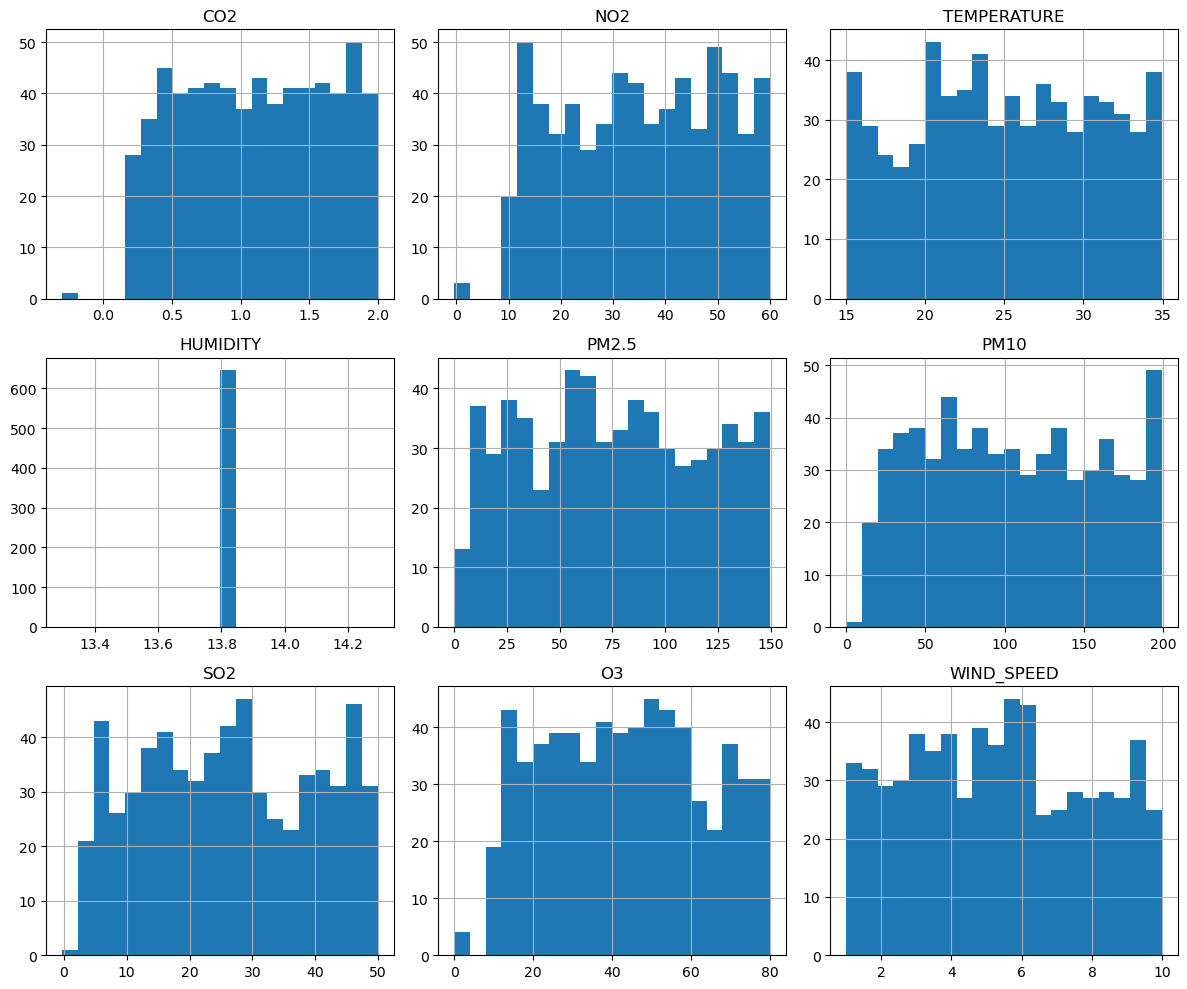

In [150]:
df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

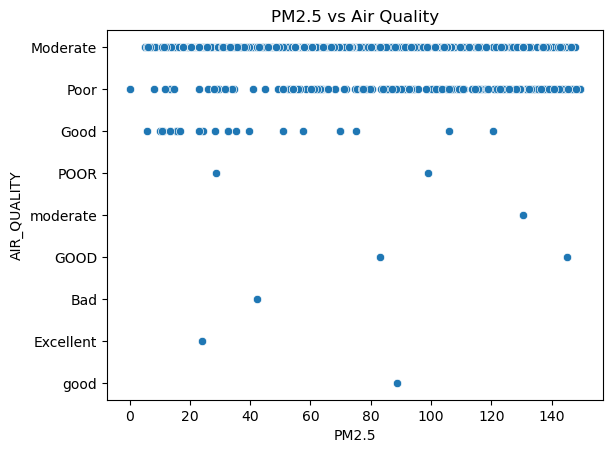

In [151]:
sns.scatterplot(x='PM2.5', y='AIR_QUALITY', data=df)
plt.title('PM2.5 vs Air Quality')
plt.show()

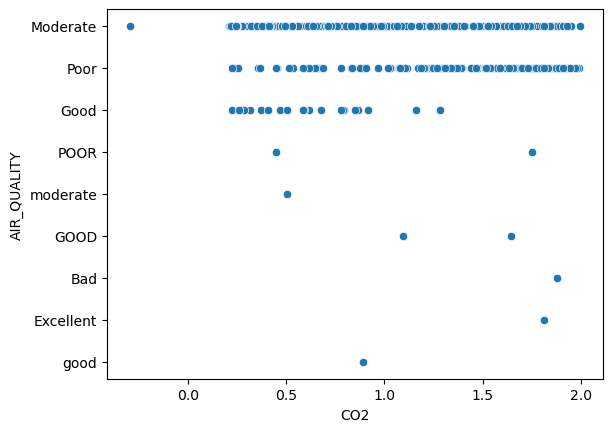

In [152]:
sns.scatterplot(x='CO2', y='AIR_QUALITY', data=df)
plt.show()

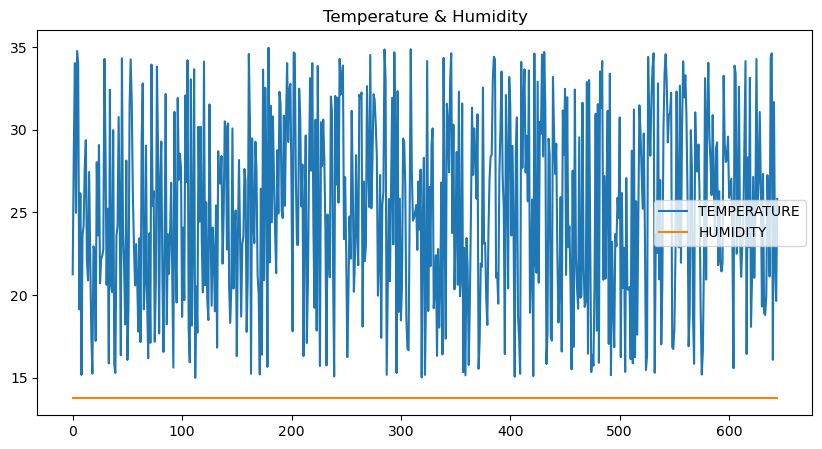

In [153]:
df[['TEMPERATURE','HUMIDITY']].plot(figsize=(10,5))
plt.title('Temperature & Humidity')
plt.show()

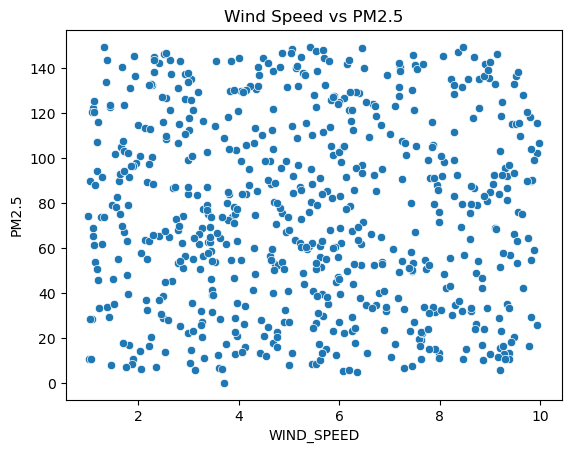

In [154]:
sns.scatterplot(x='WIND_SPEED', y='PM2.5', data=df)
plt.title('Wind Speed vs PM2.5')
plt.show()